# Task 2 — Notebook 4: Detailed EDA

## Notebook Objective

* Work only with the **training data** (`train.parquet`) and never access the Test set.
* Understand the data through **data types, missing values, distributions, relationships with the label, dates, and geographic information**.
* Record important observations and findings.
* Use the EDA results to guide **feature engineering and model selection** in the next notebooks.
* Save important visualizations in `artifacts/charts/` and keep a short summary of the main findings.

The goal is to **understand the training data before building the ML model**, since the decisions in the next stages will be based on the findings from this notebook.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

pd.set_option("display.max_columns", None)
os.makedirs("artifacts/charts", exist_ok=True)

train_df = pd.read_parquet("artifacts/train.parquet")
print("Shape:", train_df.shape)

Shape: (67529, 21)


## 1. Data Types, Size, and Memory

Before starting the analysis, we check the dataset structure to identify:

* **Numerical columns** → contain numbers.
* **Categorical columns** → contain categories such as city or state.
* **Date columns** → contain timestamps or dates.
* **ID/Text columns** → identifiers or text values that may not be directly useful for modeling.

We also check the dataset size and memory usage.

Sometimes date columns may be loaded as `object` (text), so we verify their types and convert them to `datetime` when necessary.


In [ ]:
print("Memory usage:", train_df.memory_usage(deep=True).sum() / 1024**2, "MB\n")
train_df.info()

In [ ]:
date_cols = [
    "order_purchase_timestamp", "order_approved_at",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

for col in date_cols:
    if not pd.api.types.is_datetime64_any_dtype(train_df[col]):
        train_df[col] = pd.to_datetime(train_df[col])

print(train_df[date_cols].dtypes)



### Column Classification

| Type                | Columns                                                                                                                                           |
| ------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------- |
| **ID / Identifier** | `order_id`, `customer_id`, `customer_unique_id`                                                                                                   |
| **Categorical**     | `order_status`, `customer_city`, `customer_state`, `customer_zip_code_prefix`                                                                     |
| **Date**            | `order_purchase_timestamp`, `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date`, `order_estimated_delivery_date` |
| **Numerical**       | `n_items`, `n_distinct_products`, `n_distinct_sellers`, `total_price`, `total_freight`, `n_payments`, `total_payment_value`, `max_installments`   |
| **Label**           | `is_late`                                                                                                                                         |

**Total: 21 columns**

* 3 ID columns
* 4 Categorical columns
* 5 Date columns
* 8 Numerical columns
* 1 Label


## 2. Missing Values

We check the number and location of missing values in the training data and investigate whether the missingness has a meaningful reason.

Some missing values come from the `left join`, such as orders without a matching `order_items` or `order_payments` record. These cases should be investigated before deciding how to handle the missing values.


In [ ]:
missing = train_df.isna().sum()
missing_pct = (train_df.isna().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    "n_missing": missing,
    "pct_missing": missing_pct
}).query("n_missing > 0").sort_values("n_missing", ascending=False)

missing_summary

### Missing Values Observations

* `order_approved_at`: **14 missing values (0.02%)**
* `order_delivered_carrier_date`: **1 missing value (<0.01%)**
* `n_payments`: **1 missing value (<0.01%)**
* `total_payment_value`: **1 missing value (<0.01%)**
* `max_installments`: **1 missing value (<0.01%)**

The amount of missing data is **very small**. Most missing values are likely related to incomplete records rather than a major data quality problem.

**Initial decision:** We will not delete rows at this stage. The missing values will be investigated and handled appropriately during **Feature Engineering in Notebook 5**.


## 3. Numerical Columns: Statistics, Distributions, Skewness, and Outliers

In this section, we analyze the numerical columns to understand their **basic statistics, distributions, skewness, and possible outliers**.

This helps us identify unusual values and understand the shape of the data before applying feature engineering or training the ML model.


In [5]:
numeric_cols = [
    "n_items", "n_distinct_products", "n_distinct_sellers",
    "total_price", "total_freight", "n_payments",
    "total_payment_value", "max_installments"
]

train_df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
n_items,67529.0,1.142072,0.541640,1.00,1.00,1.00,1.0,21.00
n_distinct_products,67529.0,1.037702,0.222199,1.00,1.00,1.00,1.0,7.00
n_distinct_sellers,67529.0,1.012054,0.114815,1.00,1.00,1.00,1.0,5.00
total_price,67529.0,135.888797,205.194019,2.29,45.90,85.00,149.9,13440.00
total_freight,67529.0,22.245936,20.002594,0.00,14.10,16.79,23.7,1002.29
n_payments,67528.0,1.047625,0.397223,1.00,1.00,1.00,1.0,26.00
total_payment_value,67528.0,158.173637,214.285757,10.07,61.63,104.19,175.5,13664.08
max_installments,67528.0,2.974559,2.755168,1.00,1.00,2.00,4.0,24.00


In [5]:
# skewness of each numeric column
skew_summary = train_df[numeric_cols].skew().sort_values(ascending=False)
print("Skewness (higher = more right-skewed):")
print(skew_summary)

Skewness (higher = more right-skewed):
n_payments             22.419509
total_price            10.718895
n_distinct_sellers     10.524938
total_payment_value    10.149318
total_freight           8.581743
n_items                 8.107162
n_distinct_products     7.677312
max_installments        1.592665
dtype: float64


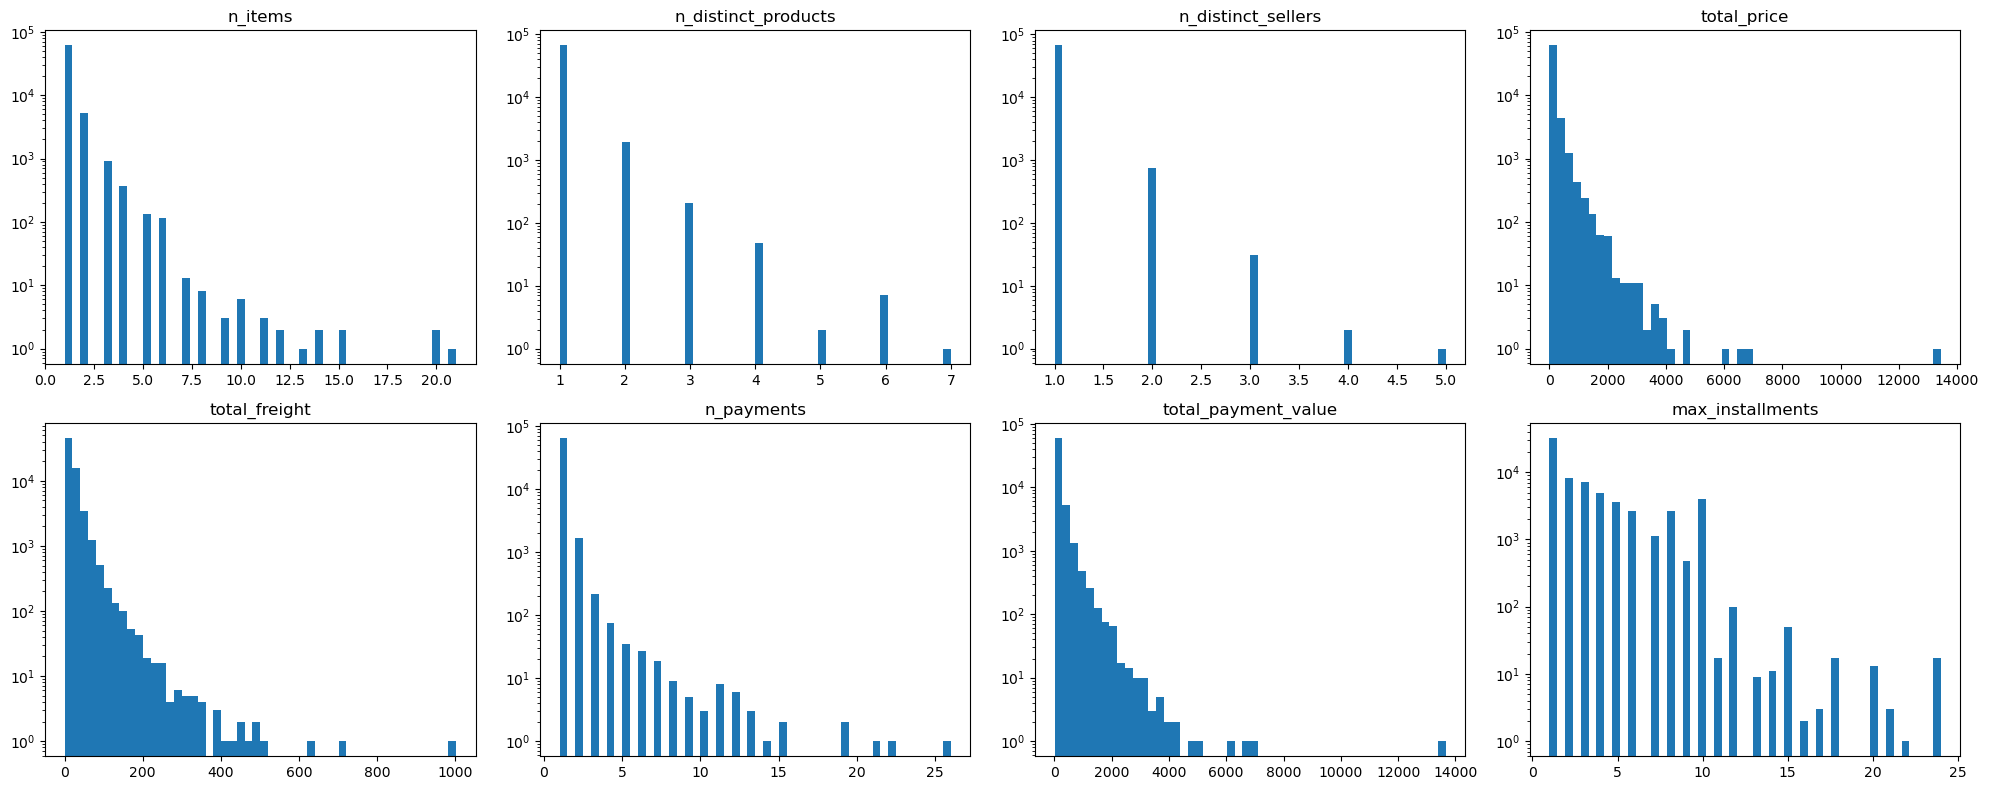

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    ax.hist(train_df[col].dropna(), bins=50)
    ax.set_title(col)
    ax.set_yscale("log")  # log scale on y since these are likely right-skewed with outliers

plt.tight_layout()
plt.savefig("artifacts/charts/numeric_distributions.png", dpi=120)
plt.show()

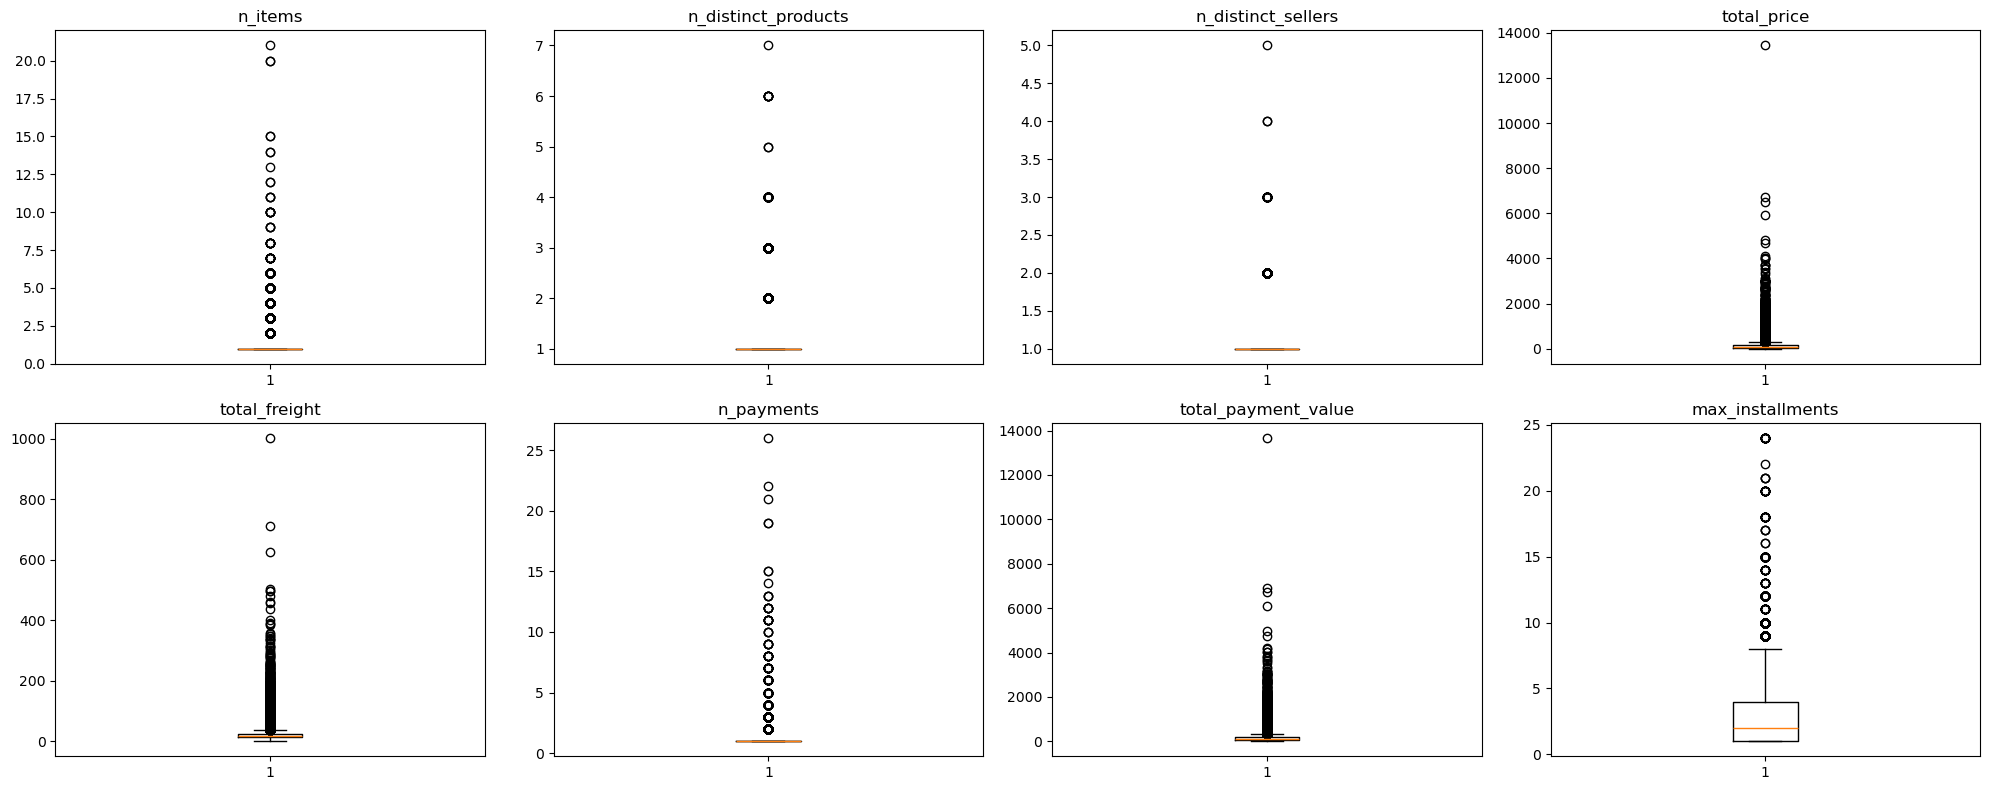

In [9]:
# boxplots to spot outliers / ranges that don't make sense
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    ax.boxplot(train_df[col].dropna())
    ax.set_title(col)

plt.tight_layout()
plt.savefig("artifacts/charts/numeric_boxplots.png", dpi=120)
plt.show()

In [8]:
# sanity check: any impossible values? (e.g. zero or negative price/freight)
print("total_price <= 0:", (train_df["total_price"] <= 0).sum())
print("total_freight < 0:", (train_df["total_freight"] < 0).sum())
print("n_items == 0:", (train_df["n_items"] == 0).sum())
print("total_payment_value <= 0:", (train_df["total_payment_value"] <= 0).sum())

total_price <= 0: 0
total_freight < 0: 0
n_items == 0: 0
total_payment_value <= 0: 0


### Numerical Features Observations

The numerical features are generally **right-skewed**, with several features showing strong skewness and many potential outliers.

The highest skewness is observed in `n_payments`, followed by `total_price`, `n_distinct_sellers`, `total_payment_value`, and `total_freight`.

The boxplots also show many outliers, especially in the price, freight, and payment-related features. These values are not necessarily errors because they may represent legitimate high-value orders.

Basic data-quality checks found no invalid values in `total_price`, `total_freight`, `n_items`, or `total_payment_value`.

**Decision:** We will keep these values for now and investigate appropriate transformations or outlier handling during Feature Engineering.


### 4 Categorical Features Analysis

We analyze the categorical features using value counts, cardinality, and rare category detection.

The goal is to understand how many unique categories each feature contains and whether some categories appear very rarely.

This analysis will help us decide how to encode and handle categorical features during Feature Engineering.


In [10]:
print("order_status unique values:")
print(train_df["order_status"].value_counts())
print()

print("customer_state — cardinality:", train_df["customer_state"].nunique())
print(train_df["customer_state"].value_counts())

order_status unique values:
order_status
delivered    67529
Name: count, dtype: int64

customer_state — cardinality: 27
customer_state
SP    27204
RJ     8965
MG     8129
RS     3912
PR     3461
SC     2576
BA     2307
ES     1445
GO     1409
DF     1404
PE     1117
CE      948
PA      718
MT      640
MA      548
MS      502
PB      370
RN      349
PI      348
AL      298
SE      246
TO      197
RO      185
AM      105
AC       66
AP       51
RR       29
Name: count, dtype: int64


In [11]:
print("customer_city — cardinality:", train_df["customer_city"].nunique())
print("\nTop 10 cities:")
print(train_df["customer_city"].value_counts().head(10))

print("\nRare cities (appear only once):", (train_df["customer_city"].value_counts() == 1).sum())

customer_city — cardinality: 3747

Top 10 cities:
customer_city
sao paulo                9920
rio de janeiro           4777
belo horizonte           1869
brasilia                 1395
curitiba                 1020
porto alegre              975
campinas                  967
salvador                  823
guarulhos                 724
sao bernardo do campo     622
Name: count, dtype: int64

Rare cities (appear only once): 1219


### Notes

* **`order_status`** — Contains only one value, `delivered`, after the filtering performed in Notebook 2, with **67,529 records**. Therefore, it is a **zero-variance (constant) feature** and provides no useful predictive information. It should be removed before model training.

* **`customer_state`** — Has **27 unique values (cardinality = 27)**, which is relatively low. Therefore, it is a suitable feature for modeling and can be encoded using **One-Hot Encoding**.

* **`customer_city`** — Has **3,747 unique cities**, with **1,219 cities appearing only once**, representing approximately **32.5% of all unique cities**. This indicates high cardinality and a large number of rare categories. Therefore, `customer_city` will be excluded from the initial modeling features, while `customer_state` will be used instead to avoid increasing dimensionality and the risk of overfitting.


## 5. العلاقات مع الـ label (`is_late`)

هون قلب الـ EDA — منشوف هل الفيتشرز الرقمية والتصنيفية عندها علاقة ملحوظة مع التأخير.

In [12]:
# numeric features: mean value per label class
groupby_label = train_df.groupby("is_late")[numeric_cols].mean().T
groupby_label.columns = ["is_late=0 (on time)", "is_late=1 (late)"]
groupby_label["diff_%"] = (
    (groupby_label["is_late=1 (late)"] - groupby_label["is_late=0 (on time)"])
    / groupby_label["is_late=0 (on time)"] * 100
).round(1)


groupby_label

,is_late=0 (on time),is_late=1 (late),diff_%
n_items,1.144824,1.114337,-2.7
n_distinct_products,1.039213,1.022474,-1.6
n_distinct_sellers,1.012990,1.002625,-1.0
total_price,134.509675,149.787024,11.4
total_freight,21.952332,25.204762,14.8
n_payments,1.048362,1.040197,-0.8
total_payment_value,156.501342,175.029112,11.8
max_installments,2.959647,3.124856,5.6


In [13]:
# correlation of numeric features with the label
correlations = train_df[numeric_cols + ["is_late"]].corr()["is_late"].drop("is_late").sort_values(key=abs, ascending=False)
print("Correlation with is_late:")
print(correlations)

Correlation with is_late:
total_freight          0.046597
n_distinct_sellers    -0.025871
total_payment_value    0.024776
n_distinct_products   -0.021589
total_price            0.021336
max_installments       0.017183
n_items               -0.016130
n_payments            -0.005890
Name: is_late, dtype: float64


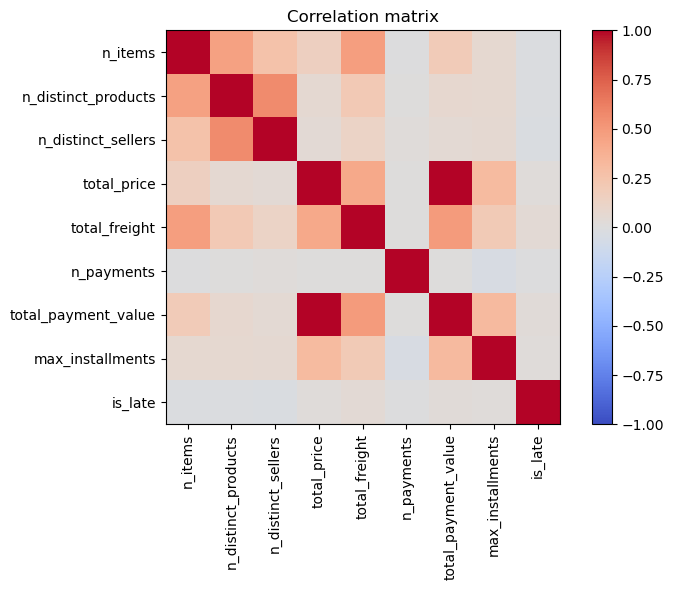

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(train_df[numeric_cols + ["is_late"]].corr(), cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols) + 1))
ax.set_yticks(range(len(numeric_cols) + 1))
ax.set_xticklabels(numeric_cols + ["is_late"], rotation=90)
ax.set_yticklabels(numeric_cols + ["is_late"])
plt.colorbar(im)
plt.title("Correlation matrix")
plt.tight_layout()
plt.savefig("artifacts/charts/correlation_matrix.png", dpi=120)
plt.show()

In [15]:
# cross-tab: late rate by customer_state (top 10 states by volume)
top_states = train_df["customer_state"].value_counts().head(10).index

state_late_rate = (
    train_df[train_df["customer_state"].isin(top_states)]
    .groupby("customer_state")["is_late"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "late_rate"})
    .sort_values("late_rate", ascending=False)
)
state_late_rate["late_rate"] = (state_late_rate["late_rate"] * 100).round(2)
state_late_rate

,late_rate,count
customer_state,,
RJ,16.59,8965
BA,15.00,2307
ES,13.29,1445
SC,11.96,2576
GO,9.58,1409
RS,8.67,3912
DF,7.98,1404
MG,6.29,8129
SP,5.59,27204


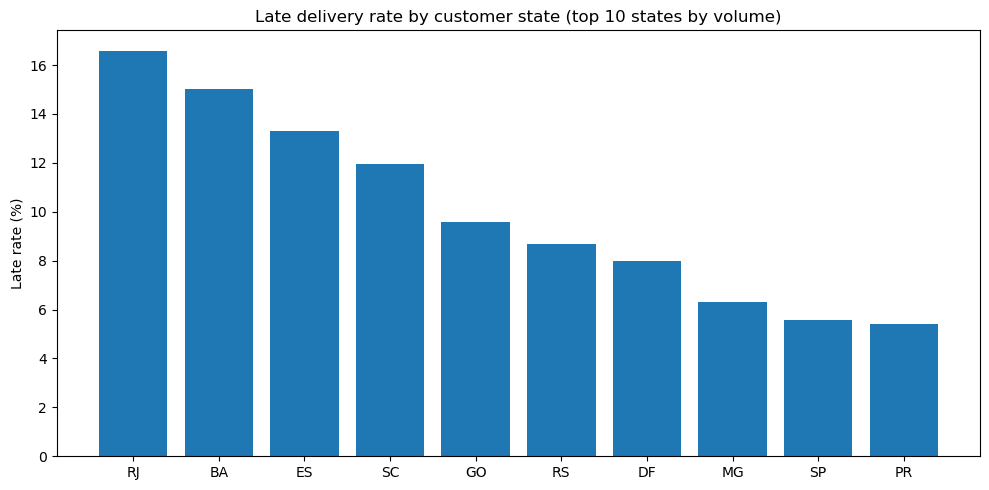

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(state_late_rate.index, state_late_rate["late_rate"])
ax.set_ylabel("Late rate (%)")
ax.set_title("Late delivery rate by customer state (top 10 states by volume)")
plt.tight_layout()
plt.savefig("artifacts/charts/late_rate_by_state.png", dpi=120)
plt.show()

**Notes:**

- **Numeric features:** all correlations with `is_late` are **very weak** — the highest (`total_freight`) is
  only 0.047, and the rest (`n_items`, `n_payments`, `n_distinct_sellers`...) are close to zero. On their own,
  order size/value don't linearly explain lateness. The groupby table above shows late orders have somewhat
  higher `total_price` and `total_freight` (+11–15%), but the difference isn't strong enough by itself to be
  a reliable signal — this could reflect a non-linear relationship or an interaction with other features
  (e.g. price combined with distance/state), which a simple linear correlation wouldn't capture.

- **customer_state — large, clear difference:** this is a very different story. The late rate ranges from
  **16.59%** in RJ to **5.43%** in PR — roughly a **3x difference** between the highest and lowest state
  (among the highest-volume states). This is a much stronger signal than any of the numeric features, and
  makes `customer_state` one of the **strongest candidate features** for the model.

- **Initial takeaway:** geography (state) matters far more than order size/value for explaining delays —
  which makes sense (distance from distribution centers, shipping carrier differences by region). This
  raises the importance of section 7 (Geography) coming up, and strengthens the case for adding
  `primary_seller_state` / `same_state` in Notebook 5.

- **Reminder:** high correlation isn't causation, and weak correlation doesn't mean "no relationship" — it
  could be non-linear or conditional. Worth revisiting with feature importance once we have a trained model.

## 6. التواريخ: مدة التوصيل، الموسمية، تأثير أيام الأسبوع

In [15]:
# actual delivery time in days (purchase -> delivered)
train_df["delivery_days"] = (
    train_df["order_delivered_customer_date"] - train_df["order_purchase_timestamp"]
).dt.days

# estimated delivery window in days (purchase -> estimated)
train_df["estimated_days"] = (
    train_df["order_estimated_delivery_date"] - train_df["order_purchase_timestamp"]
).dt.days

train_df[["delivery_days", "estimated_days"]].describe()

,delivery_days,estimated_days
count,67529.000000,67529.000000
mean,13.355995,24.231915
std,10.256213,8.015459
min,0.000000,7.000000
25%,7.000000,19.000000
50%,11.000000,23.000000
75%,17.000000,28.000000
max,209.000000,155.000000


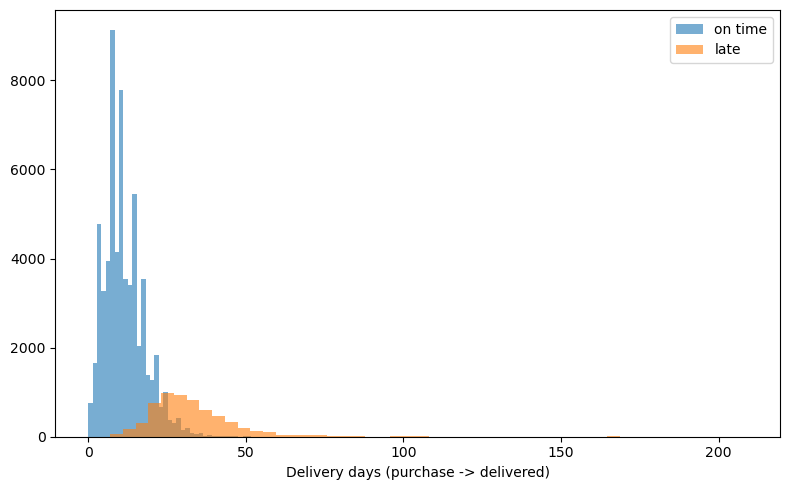

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(train_df[train_df["is_late"] == 0]["delivery_days"], bins=50, alpha=0.6, label="on time")
ax.hist(train_df[train_df["is_late"] == 1]["delivery_days"], bins=50, alpha=0.6, label="late")
ax.set_xlabel("Delivery days (purchase -> delivered)")
ax.legend()
plt.tight_layout()
plt.savefig("artifacts/charts/delivery_days_by_label.png", dpi=120)
plt.show()

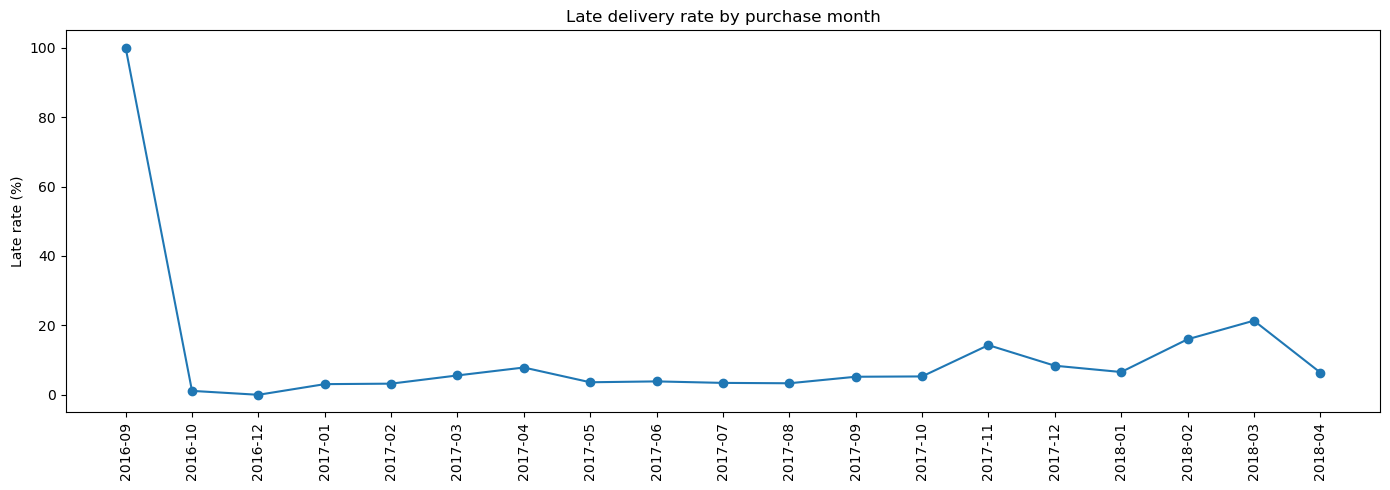

,mean,count
purchase_month,,
2016-09,100.00,1
2016-10,1.13,265
2016-12,0.00,1
2017-01,3.07,750
2017-02,3.21,1653
2017-03,5.58,2546
2017-04,7.86,2303
2017-05,3.61,3545
2017-06,3.86,3135


In [17]:
# seasonality: late rate by purchase month
train_df["purchase_month"] = train_df["order_purchase_timestamp"].dt.to_period("M").astype(str)

monthly_late_rate = train_df.groupby("purchase_month")["is_late"].agg(["mean", "count"])
monthly_late_rate["mean"] = (monthly_late_rate["mean"] * 100).round(2)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_late_rate.index, monthly_late_rate["mean"], marker="o")
ax.set_ylabel("Late rate (%)")
ax.set_title("Late delivery rate by purchase month")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("artifacts/charts/late_rate_by_month.png", dpi=120)
plt.show()

monthly_late_rate

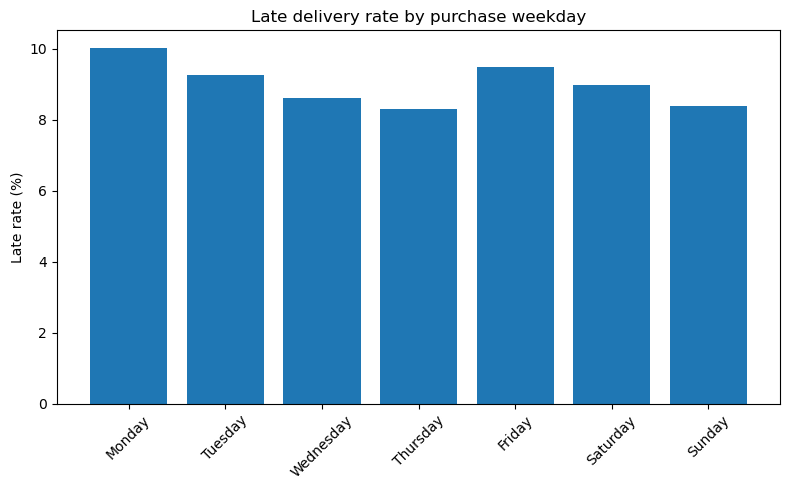

purchase_weekday
Monday       10.01
Tuesday       9.26
Wednesday     8.61
Thursday      8.29
Friday        9.47
Saturday      8.97
Sunday        8.38
Name: is_late, dtype: float64

In [18]:
# weekday effect
train_df["purchase_weekday"] = train_df["order_purchase_timestamp"].dt.day_name()

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_late_rate = (
    train_df.groupby("purchase_weekday")["is_late"]
    .mean()
    .reindex(weekday_order) * 100
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(weekday_late_rate.index, weekday_late_rate.values)
ax.set_ylabel("Late rate (%)")
ax.set_title("Late delivery rate by purchase weekday")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("artifacts/charts/late_rate_by_weekday.png", dpi=120)
plt.show()

weekday_late_rate.round(2)

**Notes:**

- **Actual delivery time (`delivery_days`):** the histogram clearly shows the late orders (orange) shifted
  to the right compared to on-time orders (blue) — expected, since `is_late` is derived from this same date.
  Mean is 13.4 days overall, but there are outliers up to 209 days — worth a closer look later (real cases
  vs. data errors). **Note: this column will never be used as a feature (leakage) — it's here purely for
  exploratory understanding.**

- **Monthly seasonality — a clear and important pattern:**
  - 2016-09 and 2016-12 only have `count = 1` each (100% and 0% respectively) — this is noise from tiny
    sample size, not a real pattern, and should be ignored or merged with enough data when building seasonal
    features.
  - Aside from those, the rate is fairly stable (3–8%) through most of 2017, **but there are clear spikes**:
    November 2017 (14.31%, n=7288 — coinciding with Brazilian Black Friday season), and an even bigger jump
    in February–March 2018 (15.99% and 21.36% respectively, also with large sample sizes — not a fluke).
    This is a strong, real pattern, not noise, and makes **the purchase month (`purchase_month`) a strong
    candidate seasonal feature** for Notebook 5 (as one-hot, or even a simpler `is_peak_season` flag based
    on Nov/Feb/Mar).

- **Weekday — weak effect:** the difference between the highest (Monday, 10.01%) and lowest (Thursday, 8.29%)
  is small (about 1.7 percentage points) — a real but weak signal compared to monthly seasonality. Might be
  worth adding as a simple feature (weekday) but it's a lower priority than the month.

- **Reminder:** `delivery_days` and `estimated_days` here are for exploration only — `delivery_days` is
  derived from `order_delivered_customer_date`, which won't be available at real prediction time (data
  leakage if used as a feature, as documented in Notebook 1). `estimated_days`, on the other hand, is
  available at prediction time and is a safe candidate feature for Notebook 5.

## 7. الجغرافيا: ولاية الزبون والبائع، المسافة، الرمز البريدي

**ملاحظة مهمة:** بنوتبوك 1 اخترنا نخلي جدول ML بسيط (بدون معلومات جغرافية عن البائع)، وأجّلنا قرار إضافة
معلومات البائع/المسافة لحد ما يكون عندنا نتيجة EDA تدعم أهميتها. هلأ منستكشف هالموضوع مباشرة من الجداول
الخام (بس للاستكشاف — ما رح نعدل على `train.parquet` هون، القرار النهائي والتنفيذ هيصير بنوتبوك 5 إذا تبين
إنه مفيد).

In [19]:
from sqlalchemy import create_engine

DB_USER = "olist_user"
DB_PASS = "olist_pass"
DB_HOST = "localhost"
DB_PORT = 5432
DB_NAME = "olist_db"

engine = create_engine(f"postgresql+psycopg2://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

order_items_raw = pd.read_sql_table("order_items", engine)
sellers_raw = pd.read_sql_table("sellers", engine)

# primary (most frequent) seller state per order, for orders in our training split only
items_sellers = order_items_raw.merge(sellers_raw, on="seller_id", how="left")
items_sellers = items_sellers[items_sellers["order_id"].isin(train_df["order_id"])]

def mode_or_none(s):
    m = s.mode()
    return m.iloc[0] if not m.empty else None

seller_state_per_order = (
    items_sellers.groupby("order_id")["seller_state"]
    .agg(mode_or_none)
    .rename("primary_seller_state")
    .reset_index()
)

train_geo = train_df.merge(seller_state_per_order, on="order_id", how="left")

# is customer and seller in the same state?
train_geo["same_state"] = train_geo["customer_state"] == train_geo["primary_seller_state"]

print("Missing primary_seller_state:", train_geo["primary_seller_state"].isna().sum())
print("\nLate rate when customer & seller are in the same state:")
print(train_geo.groupby("same_state")["is_late"].agg(["mean", "count"]))

Missing primary_seller_state: 0

Late rate when customer & seller are in the same state:
                mean  count
same_state                 
False       0.108628  44473
True        0.054866  23056


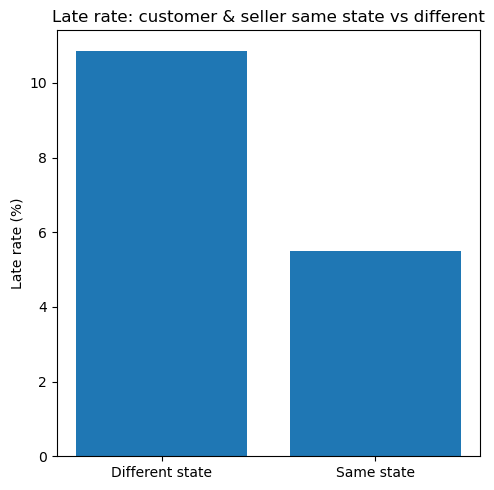

In [20]:
fig, ax = plt.subplots(figsize=(5, 5))
rates = train_geo.groupby("same_state")["is_late"].mean() * 100
ax.bar(["Different state", "Same state"], rates.values)
ax.set_ylabel("Late rate (%)")
ax.set_title("Late rate: customer & seller same state vs different")
plt.tight_layout()
plt.savefig("artifacts/charts/late_rate_same_state.png", dpi=120)
plt.show()

**Notes:**

- **Clear, large difference:** the late rate is **10.86%** when customer and seller are in *different* states
  (n=44,473) vs **5.49%** when they're in the *same* state (n=23,056) — roughly **2x higher** when
  cross-state. `primary_seller_state` was successfully matched for every order (0 missing), so this feature
  is fully usable with no coverage gaps.

- **Decision:** this confirms the signal already seen in section 5 (customer state alone had a ~3x spread
  across states) — seller/customer geography is one of the strongest predictors of lateness found in this
  EDA, clearly outweighing the numeric order-size features. Both `primary_seller_state` and the simpler
  binary `same_state` flag are strong candidates to add as real features in Notebook 5. `same_state` in
  particular is cheap to compute, has zero missing values, and captures most of the signal in a single
  binary column — a good first feature to try before adding the full categorical seller state.

- **Note:** this analysis pulled seller data directly from the raw database tables (not through the current
  `ml_table`), since Notebook 1 was kept intentionally minimal. The actual decision to add these columns,
  and the pipeline implementation, will happen in Notebook 5 — not here.

## 8. Findings Summary

### 1. Top features correlated with lateness

- **`customer_state`** — strongest categorical signal found: late rate ranges from 16.59% (RJ) to 5.43% (PR),
  roughly a 3x spread across the highest-volume states.
- **`same_state`** (customer & seller in the same state) — 5.49% late rate when same state vs. 10.86% when
  different states (~2x difference), fully computable with zero missing values.
- **`primary_seller_state`** — same underlying signal as `same_state`, at finer granularity (0 missing after
  matching against raw seller data).
- **`purchase_month`** — clear seasonal spikes around Nov 2017 (Black Friday, 14.31%) and Feb–Mar 2018
  (15.99%, 21.36%), all with large sample sizes.
- **`total_freight` / `total_price`** — weak standalone linear signal (correlation ≈ 0.02–0.05), but late
  orders do run ~11–15% higher on average — likely useful in combination with geography rather than alone.

### 2. Features needing preprocessing

- **Right-skewed numeric features** (`n_payments`, `total_price`, `n_distinct_sellers`, `total_payment_value`,
  `total_freight`) — will need log-transform or similar during Feature Engineering.
- **Outliers** in price/freight/payment fields — not necessarily errors (could be legitimate high-value
  orders); to be reviewed further, not removed outright.
- **Missing values** (`order_approved_at`: 14, `order_delivered_carrier_date`: 1, `n_payments`: 1,
  `total_payment_value`: 1, `max_installments`: 1) — negligible (<0.02%), no rows dropped now; will be
  imputed or handled in Notebook 5.
- **`purchase_weekday`** — weak but real signal (~1.7 pt spread); low priority, can be added cheaply.

### 3. Features to exclude

- **`order_status`** — zero variance (only `delivered` remains after Notebook 2 filtering) — no predictive
  value, will be dropped.
- **`customer_city`** — high cardinality (3,747 unique values, 32.5% appearing only once) — excluded in favor
  of `customer_state`, which captures similar geographic signal at much lower dimensionality and overfitting
  risk.
- **`delivery_days`** (and any column derived from `order_delivered_customer_date`) — data leakage, not
  available at real prediction time; excluded from features entirely (kept only for this EDA).

### 4. Geography decision

**Yes** — add `primary_seller_state` and/or `same_state` in Notebook 5. This was one of the strongest signals
found in the entire EDA (~2–3x spread in late rate), clearly outweighing the numeric order-size features, and
has full coverage (0 missing). `same_state` is the cheapest first feature to try (single binary column);
`primary_seller_state` / `customer_state` can be added as categorical features alongside it.

### 5. Class imbalance reminder

From Notebook 2: **91.89% on-time vs. 8.11% late** (~11:1 ratio). Accuracy alone would be misleading (a model
that always predicts "on time" would score ~92% while learning nothing useful). Notebook 6 must use a metric
that accounts for the minority class (F1-score, Precision/Recall on `is_late=1`, or PR-AUC), and may need
class weighting or resampling strategies during training.

In [22]:
findings = """
EDA Findings Summary — Notebook 4
==================================

1. Top features correlated with is_late:
   - customer_state: late rate ranges from 16.59% (RJ) to 5.43% (PR) across top-volume states (~3x spread)
   - same_state (customer & seller): 5.49% late when same state vs 10.86% when different (~2x difference)
   - primary_seller_state: same signal as same_state, finer granularity, 0 missing values
   - purchase_month: clear seasonal spikes in Nov 2017 (Black Friday, 14.31%) and Feb-Mar 2018 (15.99%, 21.36%)
   - total_freight / total_price: weak standalone correlation (~0.02-0.05), but late orders run ~11-15% higher
     on average, likely useful combined with geography

2. Features needing preprocessing:
   - Right-skewed numeric features (n_payments, total_price, n_distinct_sellers, total_payment_value,
     total_freight) need log-transform or similar
   - Outliers in price/freight/payment fields are not necessarily errors, to be reviewed further
   - Missing values are negligible (<0.02%): order_approved_at (14), order_delivered_carrier_date (1),
     n_payments (1), total_payment_value (1), max_installments (1) - no rows dropped, will impute in NB5
   - purchase_weekday: weak but real signal (~1.7pt spread), low priority

3. Features to exclude:
   - order_status: zero variance (only "delivered" remains after NB2 filtering), no predictive value
   - customer_city: high cardinality (3,747 unique, 32.5% appearing only once), excluded in favor of
     customer_state
   - delivery_days (and anything derived from order_delivered_customer_date): data leakage, not available
     at prediction time, excluded from features entirely

4. Geography decision:
   - Yes, add primary_seller_state and/or same_state in Notebook 5. One of the strongest signals found in
     the entire EDA (~2-3x spread in late rate), full coverage (0 missing). same_state is the cheapest first
     feature to try; primary_seller_state / customer_state can be added as categorical features alongside it.

5. Class imbalance reminder:
   - From Notebook 2: 91.89% on-time vs 8.11% late (~11:1 ratio). Accuracy alone is misleading. Notebook 6
     must use a metric that accounts for the minority class (F1-score, Precision/Recall on is_late=1, or
     PR-AUC), and may need class weighting or resampling during training.
"""

with open("artifacts/eda_findings.md", "w", encoding="utf-8") as f:
    f.write(findings)

print("Saved artifacts/eda_findings.md")

Saved artifacts/eda_findings.md
